Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [2]:
df = pd.read_csv("/content/anime.csv")
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


Exploratory Data Analysis

Dataset Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


Shape

In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 12294
Columns: 7


Missing Values

---



In [6]:
df.isnull().sum()

,0
anime_id,0
name,0
genre,62
type,25
episodes,0
rating,230
members,0


Statistical Summary

In [7]:
df.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


Data Cleaning

Replace Unknown values

In [8]:
df.replace("Unknown", np.nan, inplace=True)

Convert Episodes column

In [9]:
df['episodes'] = pd.to_numeric(df['episodes'], errors='coerce')

Fill Missing Ratings

In [10]:
df['rating'].fillna(df['rating'].median(), inplace=True)

/tmp/ipykernel_5425/333645285.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rating'].fillna(df['rating'].median(), inplace=True)


Fill Missing Episodes

In [11]:
df['episodes'].fillna(df['episodes'].median(), inplace=True)

/tmp/ipykernel_5425/3609485322.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['episodes'].fillna(df['episodes'].median(), inplace=True)


Drop rows where genre is missing

In [12]:
df = df.dropna(subset=['genre'])

Data Visualization

Ratings Distribution


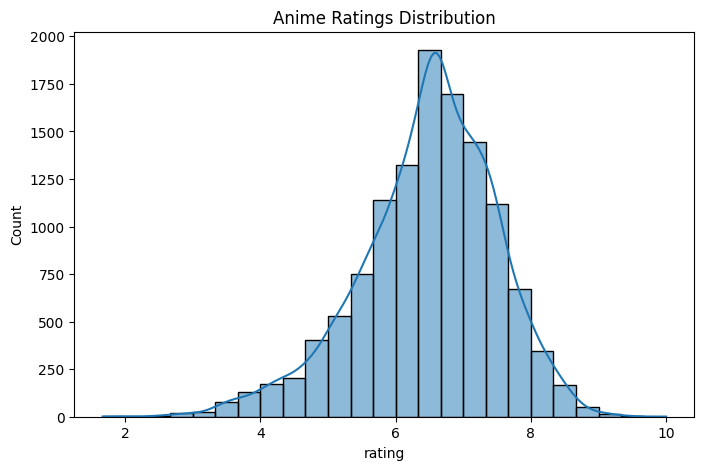

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['rating'], bins=25, kde=True)
plt.title("Anime Ratings Distribution")
plt.show()

Episodes Distribution

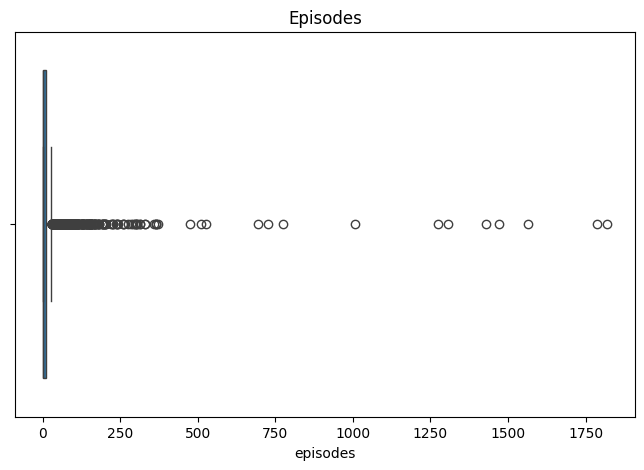

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['episodes'])
plt.title("Episodes")
plt.show()

Type Count

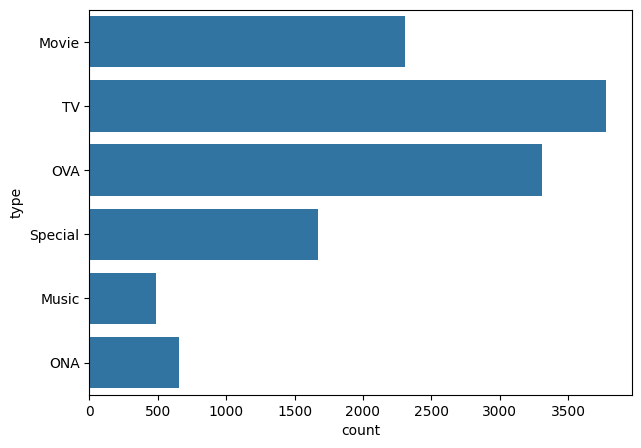

In [15]:
plt.figure(figsize=(7,5))
sns.countplot(y=df['type'])
plt.show()

Feature Extraction

In [16]:
genres = df['genre'].str.split(',')

In [17]:
mlb = MultiLabelBinarizer()

genre_matrix = pd.DataFrame(
    mlb.fit_transform(genres),
    columns=mlb.classes_,
    index=df.index
)

Normalize Numerical Features

In [21]:
scaler = MinMaxScaler()

numeric_features = scaler.fit_transform(
    df[['rating','episodes','members']]
)

numeric_df = pd.DataFrame(
    numeric_features,
    columns=['rating','episodes','members'],
    index=df.index
)

Combine Features

In [22]:
feature_matrix = pd.concat(
    [genre_matrix, numeric_df],
    axis=1
)

Cosine Similarity

In [25]:
similarity = cosine_similarity(feature_matrix)

Convert into DataFrame

In [24]:
similarity_df = pd.DataFrame(
    similarity,
    index=df['name'],
    columns=df['name']
)

Recommendation Function

In [26]:
def recommend_anime(title, n=10):

    if title not in similarity_df.columns:
        return "Anime not found"

    scores = similarity_df[title]

    scores = scores.sort_values(ascending=False)

    recommendations = scores.iloc[1:n+1]

    return recommendations

In [27]:
recommend_anime("Naruto")

,Naruto
name,
Naruto: Shippuuden,0.997027
Naruto: Shippuuden Movie 4 - The Lost Tower,0.969302
Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsugu Mono,0.969183
Boruto: Naruto the Movie,0.968273
Naruto x UT,0.962834
Naruto Soyokazeden Movie: Naruto to Mashin to Mitsu no Onegai Dattebayo!!,0.962540
Boruto: Naruto the Movie - Naruto ga Hokage ni Natta Hi,0.962132
Naruto Shippuuden: Sunny Side Battle,0.961379
Katekyo Hitman Reborn!,0.896521


Recommendation with Threshold

In [28]:
def recommend_threshold(title, threshold=0.70):

    if title not in similarity_df.columns:
        return "Anime not found"

    scores = similarity_df[title]

    scores = scores[scores > threshold]

    scores = scores.sort_values(ascending=False)

    return scores.iloc[1:]

In [29]:
recommend_threshold("Death Note",0.80)

,Death Note
name,
Death Note Rewrite,0.935399
Higurashi no Naku Koro ni Kai,0.871989


Experiment with Different Thresholds

In [30]:
for t in [0.50,0.60,0.70,0.80,0.90]:

    rec = recommend_threshold("Naruto",t)

    print("Threshold:",t)

    print("Recommendations:",len(rec))

Threshold: 0.5
Recommendations: 827
Threshold: 0.6
Recommendations: 416
Threshold: 0.7
Recommendations: 124
Threshold: 0.8
Recommendations: 26
Threshold: 0.9
Recommendations: 8


Recommendation Example

In [32]:
anime = input("Enter Anime Name : ")

print(recommend_anime(anime))

Enter Anime Name : Kimi no Na wa.
name
Wind: A Breath of Heart OVA                              0.983501
Wind: A Breath of Heart (TV)                             0.981817
Clannad: After Story - Mou Hitotsu no Sekai, Kyou-hen    0.889102
Kokoro ga Sakebitagatterunda.                            0.888324
Angel Beats!: Another Epilogue                           0.887303
True Tears                                               0.886629
Myself; Yourself                                         0.885777
Kimikiss Pure Rouge                                      0.884694
Koi to Senkyo to Chocolate                               0.884602
Harmonie                                                 0.883873
Name: Kimi no Na wa., dtype: float64


In [33]:
anime = input("Enter Anime Name : ")

print(recommend_anime(anime))

Enter Anime Name : Ginga Eiyuu Densetsu
name
Ginga Eiyuu Densetsu Gaiden: Rasen Meikyuu                                         0.997922
Starship Operators                                                                 0.993708
Uchuu Senkan Yamato (Movie)                                                        0.993162
Ginga Patrol PJ                                                                    0.990832
Mobile Suit Zeta Gundam                                                            0.904331
Mobile Suit Gundam: Char&#039;s Counterattack                                      0.902624
Mobile Suit Gundam Seed Destiny Final Plus: The Chosen Future                      0.900851
Mobile Suit Zeta Gundam: A New Translation III - Love Is the Pulse of the Stars    0.899417
Mobile Suit Zeta Gundam: A New Translation - Heir to the Stars                     0.899278
Mobile Suit Victory Gundam                                                         0.896706
Name: Ginga Eiyuu Densetsu, dtype: 

anime = input("Enter Anime Name : ")

print(recommend_anime(anime))

Can you explain the difference between User-Based and Item-Based Collaborative Filtering?

User-Based and Item-Based Collaborative Filtering are two recommendation techniques that use user behavior instead of item features.

User-Based Collaborative Filtering:

It identifies users who have similar preferences.
If two users have rated many items similarly, the system assumes they have similar tastes.
It recommends items liked by similar users that the target user has not seen.

Example:
If I like Naruto and One Piece, and another user also likes these anime but has additionally watched Bleach, the system recommends Bleach to me.

Item-Based Collaborative Filtering:

It finds items that are similar based on user ratings.
If users who liked Naruto also liked Bleach, then Bleach will be recommended to anyone who likes Naruto.

Key Difference:

User-Based compares users with users.
Item-Based compares items with items.

What is Collaborative Filtering, and how does it work?

Collaborative Filtering is a recommendation technique that suggests items to users based on the preferences and behavior of other users with similar interests. It does not require detailed information about the items themselves; instead, it relies on user interactions such as ratings, purchases, or watch history.

How it works:

Collect user interaction data (ratings, clicks, purchases, etc.).
Find similarities between users or between items.
Predict which items the user is likely to enjoy.
Recommend the items with the highest predicted ratings.

Example:
Suppose many users who watched Death Note also watched Code Geass. If I have watched Death Note but not Code Geass, the system recommends Code Geass to me.